In [1]:
import numpy as np
from dual_pol import *
from dual_pol import (
    _get_nexrad_reflectivity_ppi_data,
    _reflectivity_dbz_to_rgba,
    _get_nexrad_ppi_data_cached,
    _get_nexrad_archive_volume,
    _get_nexrad_best_sweep_for_field,
    _get_nexrad_rhohv_ppi_data,
)
import pyart
import matplotlib.pyplot as plt

objc[5367]: Class AVFFrameReceiver is implemented in both /Users/marshall/.venvs/dsp/lib/python3.13/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x11fc483a8) and /Users/marshall/.venvs/dsp/lib/python3.13/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x14c9883a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[5367]: Class AVFAudioReceiver is implemented in both /Users/marshall/.venvs/dsp/lib/python3.13/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x11fc483f8) and /Users/marshall/.venvs/dsp/lib/python3.13/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x14c9883f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.



## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
s3_key = "2024/05/07/KTLX/KTLX20240507_023811_V06"
sweep = 6
max_range_km = 150.0
resolution = 1200
zdr = _get_nexrad_ppi_data_cached(
    s3_key=s3_key,
    sweep=sweep,
    max_range_km=max_range_km,
    resolution=resolution,
    field_name="differential_reflectivity",
)

In [3]:
raw_path = _get_nexrad_archive_volume(s3_key=s3_key)
radar = pyart.io.read_nexrad_archive(str(raw_path))
# if sweep < 0 or sweep >= radar.nsweeps:
#     sweep = _get_nexrad_best_sweep_for_field(
#         s3_key=s3_key,
#         requested_sweep=sweep,
#         field_name=field_name,
#     )
# field_data = np.ma.filled(radar.get_field(sweep, field_name).astype(np.float32), np.nan)

In [4]:
rhohv_metadata = _get_nexrad_rhohv_ppi_data(
    s3_key=s3_key,
    sweep=sweep,
    max_range_km=max_range_km,
    resolution=resolution,
)

In [30]:
# zdr["field_data"][rhohv_metadata["rhohv"] < 0.8]
rho = rhohv_metadata["rhohv"].copy()
rho = np.nan_to_num(rho, nan=1)
np.nansum(rho >= 0.8) - rho.size
np.where(rho < 0.8)

(array([   7,    7,    7, ..., 1198, 1198, 1198], shape=(362828,)),
 array([673, 674, 675, ..., 592, 593, 594], shape=(362828,)))

In [23]:
rho.size

1440000

In [11]:
metadata

{'station': 'KTLX',
 'scan_time': '2024-05-07 02:38:11 UTC',
 'elevation_deg': 0.48,
 'vcp_pattern': 212,
 'sweep': 0,
 'max_range_km': 150.0,
 'field_name': 'reflectivity',
 'units': 'dBZ',
 'vmin': -20.0,
 'vmax': 75.0,
 'source': 'Unidata NEXRAD Level II archive on AWS S3',
 'valid_mask': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],
       shape=(1200, 1200)),
 'azimuth_grid_deg': array([[315.      , 315.04782 , 315.09573 , ...,  44.904266,  44.95218 ,
          45.      ],
        [314.95218 , 315.      , 315.0479  , ...,  44.952087,  45.      ,
          45.04782 ],
        [314.90427 , 314.9521  , 315.      , ...,  45.      ,  45.047913,
          45.095734],
        ...,
   

In [3]:
metadata = _get_nexrad_reflectivity_ppi_data()
rgba = _reflectivity_dbz_to_rgba(
    metadata["reflectivity_dbz"],
    valid_mask=metadata["valid_mask"],
    vmin=metadata["vmin"],
    vmax=metadata["vmax"],
)

In [4]:
list(zdr.keys())

['station',
 'scan_time',
 'elevation_deg',
 'vcp_pattern',
 'sweep',
 'max_range_km',
 'field_name',
 'units',
 'vmin',
 'vmax',
 'source',
 'field_data',
 'valid_mask',
 'azimuth_grid_deg',
 'range_grid_km',
 'x_coords_km',
 'y_coords_km']

In [5]:
metadata

{'station': 'KTLX',
 'scan_time': '2024-05-07 02:38:11 UTC',
 'elevation_deg': 0.48,
 'vcp_pattern': 212,
 'sweep': 0,
 'max_range_km': 150.0,
 'field_name': 'reflectivity',
 'units': 'dBZ',
 'vmin': -20.0,
 'vmax': 75.0,
 'source': 'Unidata NEXRAD Level II archive on AWS S3',
 'valid_mask': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],
       shape=(1200, 1200)),
 'azimuth_grid_deg': array([[315.      , 315.04782 , 315.09573 , ...,  44.904266,  44.95218 ,
          45.      ],
        [314.95218 , 315.      , 315.0479  , ...,  44.952087,  45.      ,
          45.04782 ],
        [314.90427 , 314.9521  , 315.      , ...,  45.      ,  45.047913,
          45.095734],
        ...,
   

In [6]:
angle = 0  # deg
angle_idx = np.nanargmin(np.abs(metadata["azimuth_grid_deg"][0] - angle))
angle_idx

np.int64(600)

(0.0, 360.0)

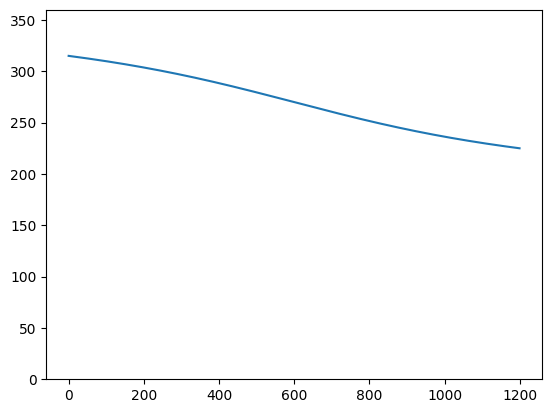

In [7]:
plt.plot(metadata["azimuth_grid_deg"][:, 0])
plt.ylim(0, 360)

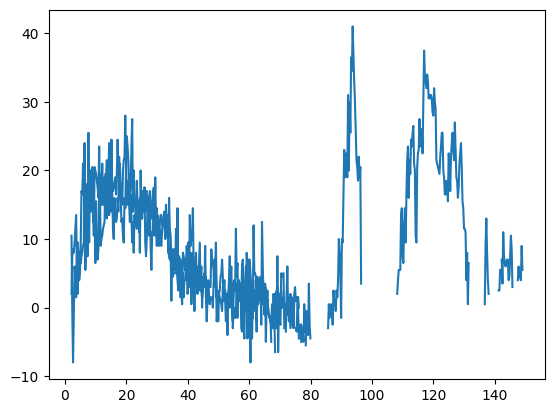

In [13]:
z = metadata["reflectivity_dbz"][angle_idx]
r = metadata["range_grid_km"][angle_idx]

plt.plot(r, z)

In [14]:
metadata

{'station': 'KTLX',
 'scan_time': '2024-05-07 02:38:11 UTC',
 'elevation_deg': 1.32,
 'vcp_pattern': 212,
 'sweep': 6,
 'max_range_km': 150.0,
 'field_name': 'reflectivity',
 'units': 'dBZ',
 'vmin': -20.0,
 'vmax': 75.0,
 'source': 'Unidata NEXRAD Level II archive on AWS S3',
 'valid_mask': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],
       shape=(1200, 1200)),
 'azimuth_grid_deg': array([[315.      , 315.04782 , 315.09573 , ...,  44.904266,  44.95218 ,
          45.      ],
        [314.95218 , 315.      , 315.0479  , ...,  44.952087,  45.      ,
          45.04782 ],
        [314.90427 , 314.9521  , 315.      , ...,  45.      ,  45.047913,
          45.095734],
        ...,
   

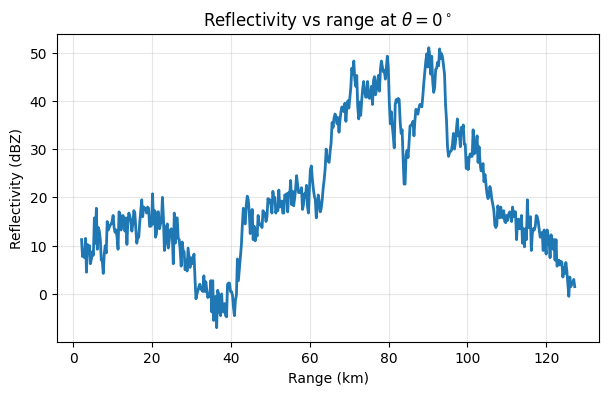

In [15]:
theta = 90.0  # degrees, north
# 1200 is even, so x=0 lies between two columns; average the two closest
x0 = np.argsort(np.abs(metadata["x_coords_km"]))[:2]
north = metadata["y_coords_km"] >= 0
r = metadata["range_grid_km"][north][:, x0].mean(axis=1)
z = np.nanmean(metadata["reflectivity_dbz"][north][:, x0], axis=1)
valid = np.any(metadata["valid_mask"][north][:, x0], axis=1)
order = np.argsort(r)
r = r[order]
z = z[order]
valid = valid[order]
plt.figure(figsize=(7, 4))
plt.plot(r[valid], z[valid], lw=2)
plt.xlabel("Range (km)")
plt.ylabel("Reflectivity (dBZ)")
plt.title(r"Reflectivity vs range at $\theta = 0^\circ$")
plt.grid(alpha=0.3)

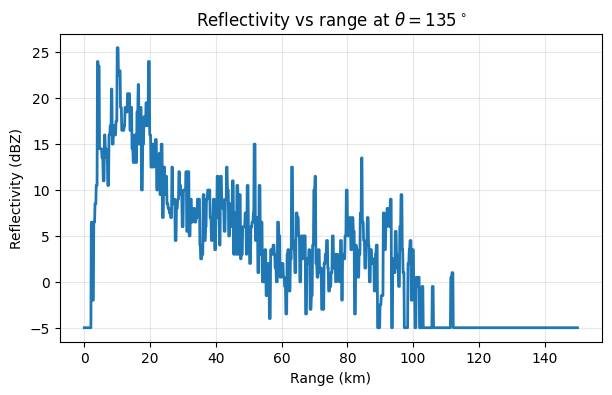

In [16]:
theta = 135.0  # degrees, 0=north, 90=east
max_range = metadata["max_range_km"]
# sample points along the desired radial
r = np.linspace(0, max_range, 1200)
# convert polar -> Cartesian using your azimuth convention
# x points east, y points north
x = r * np.sin(np.deg2rad(theta))
y = r * np.cos(np.deg2rad(theta))
# nearest-neighbor lookup into the gridded raster
x_idx = np.abs(metadata["x_coords_km"][None, :] - x[:, None]).argmin(axis=1)
y_idx = np.abs(metadata["y_coords_km"][None, :] - y[:, None]).argmin(axis=1)
z = metadata["reflectivity_dbz"][y_idx, x_idx]
z = np.nan_to_num(z, nan=-5)
valid = metadata["valid_mask"][y_idx, x_idx]
plt.figure(figsize=(7, 4))
plt.plot(r, z, lw=2)
plt.xlabel("Range (km)")
plt.ylabel("Reflectivity (dBZ)")
plt.title(rf"Reflectivity vs range at $\theta = {theta:.0f}^\circ$")
plt.grid(alpha=0.3)

In [20]:
metadata

{'station': 'KTLX',
 'scan_time': '2024-05-07 02:38:11 UTC',
 'elevation_deg': 1.32,
 'vcp_pattern': 212,
 'sweep': 6,
 'max_range_km': 150.0,
 'field_name': 'reflectivity',
 'units': 'dBZ',
 'vmin': -20.0,
 'vmax': 75.0,
 'source': 'Unidata NEXRAD Level II archive on AWS S3',
 'valid_mask': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],
       shape=(1200, 1200)),
 'azimuth_grid_deg': array([[315.      , 315.04782 , 315.09573 , ...,  44.904266,  44.95218 ,
          45.      ],
        [314.95218 , 315.      , 315.0479  , ...,  44.952087,  45.      ,
          45.04782 ],
        [314.90427 , 314.9521  , 315.      , ...,  45.      ,  45.047913,
          45.095734],
        ...,
   

88.19849874895746


(73.0, 77.0)

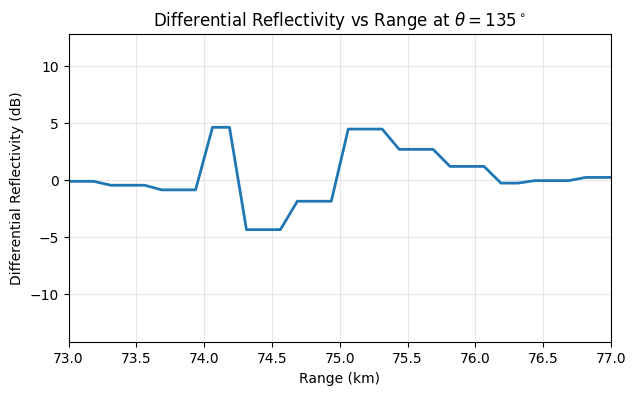

In [ ]:
theta = 135.0  # degrees, 0=north, 90=east

max_range = zdr["max_range_km"]

r = np.linspace(0, max_range, 1200)
x = r * np.sin(np.deg2rad(theta))
y = r * np.cos(np.deg2rad(theta))

x_idx = np.abs(zdr["x_coords_km"][None, :] - x[:, None]).argmin(axis=1)
y_idx = np.abs(zdr["y_coords_km"][None, :] - y[:, None]).argmin(axis=1)

z = zdr["field_data"][y_idx, x_idx]
z = np.nan_to_num(z, nan=0)

valid = zdr["valid_mask"][y_idx, x_idx]

plt.figure(figsize=(7, 4))
plt.plot(r, z, lw=2)
plt.xlabel("Range (km)")
plt.ylabel("Differential Reflectivity (dB)")
plt.title(rf"Differential Reflectivity vs Range at $\theta = {theta:.0f}^\circ$")
plt.grid(alpha=0.3)

mask = r > 40
z_masked = np.where(mask, np.abs(z), np.inf)
zero_range_idx = np.nanargmin(z_masked)
xmin = r[zero_range_idx]
print(xmin)
plt.axvline(
    xmin,
    color="r",
    ls="--",
    label=f"ZDR ≈ 0 at {r[zero_range_idx]:.1f} km",
)
plt.xlim(
    73,
)

In [42]:
np.nanargmin(np.abs(zdr["field_data"]))

np.int64(15109)